In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['digits_pca_tsne_umap_dataset.csv',
 'placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv',
 'placement_predict_50k_adjusted (1).csv',
 'student_data.csv',
 'xgboost_lightgbm_shap_student_dataset.csv',
 'iris_dataset.csv',
 'breast_cancer_classification_dataset (1).csv',
 'mall_customers_clustering_dataset.csv']

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

Dataset:
   pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  \
0      0.0      0.0      5.0     13.0      9.0      1.0      0.0      0.0   
1      0.0      0.0      0.0     12.0     13.0      5.0      0.0      0.0   
2      0.0      0.0      0.0      4.0     15.0     12.0      0.0      0.0   
3      0.0      0.0      7.0     15.0     13.0      1.0      0.0      0.0   
4      0.0      0.0      0.0      1.0     11.0      0.0      0.0      0.0   

   pixel_8  pixel_9  ...  pixel_55  pixel_56  pixel_57  pixel_58  pixel_59  \
0      0.0      0.0  ...       0.0       0.0       0.0       6.0      13.0   
1      0.0      0.0  ...       0.0       0.0       0.0       0.0      11.0   
2      0.0      0.0  ...       0.0       0.0       0.0       0.0       3.0   
3      0.0      8.0  ...       0.0       0.0       0.0       7.0      13.0   
4      0.0      0.0  ...       0.0       0.0       0.0       0.0       2.0   

   pixel_60  pixel_61  pixel_62  pixel_63  target  
0      

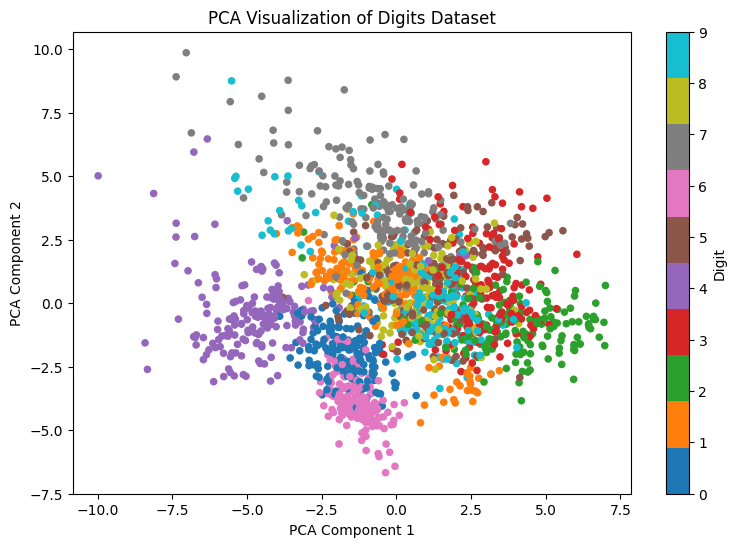

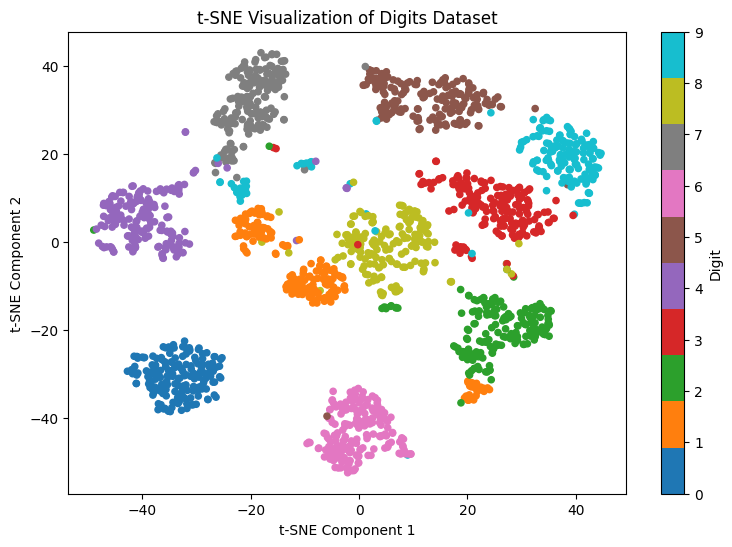

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


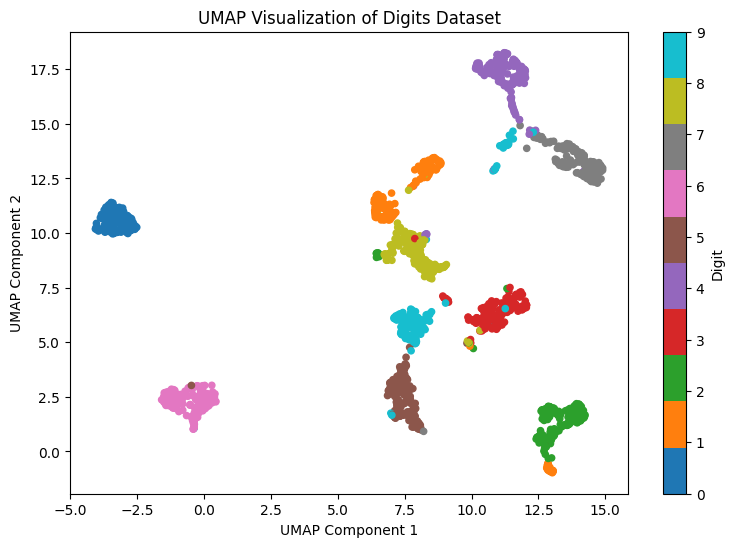


PROJECT COMPLETED SUCCESSFULLY

Generated files:
1. pca_output.csv
2. tsne_output.csv
3. umap_output.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import umap.umap_ as umap


# ==========================================
# 1. LOAD DATASET
# ==========================================

data = pd.read_csv('/content/drive/MyDrive/Colab/digits_pca_tsne_umap_dataset.csv')

print("Dataset:")
print(data.head())

print("\nDataset Shape:")
print(data.shape)


# ==========================================
# 2. SEPARATE FEATURES AND TARGET
# ==========================================

X = data.drop("target", axis=1)
y = data["target"]


# ==========================================
# 3. STANDARDIZE DATA
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# ==========================================
# 4. PCA
# ==========================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("\nPCA Explained Variance:")
print(pca.explained_variance_ratio_)

print(
    "\nTotal PCA Explained Variance:",
    sum(pca.explained_variance_ratio_)
)


# ==========================================
# 5. PCA VISUALIZATION
# ==========================================

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="tab10",
    s=20
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Visualization of Digits Dataset")

plt.colorbar(scatter, label="Digit")

plt.show()


# ==========================================
# 6. t-SNE
# ==========================================

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    learning_rate="auto",
    init="pca"
)

X_tsne = tsne.fit_transform(X_scaled)


# ==========================================
# 7. t-SNE VISUALIZATION
# ==========================================

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y,
    cmap="tab10",
    s=20
)

plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.title("t-SNE Visualization of Digits Dataset")

plt.colorbar(scatter, label="Digit")

plt.show()


# ==========================================
# 8. UMAP
# ==========================================

umap_model = umap.UMAP(
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)


# ==========================================
# 9. UMAP VISUALIZATION
# ==========================================

plt.figure(figsize=(9, 6))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=y,
    cmap="tab10",
    s=20
)

plt.xlabel("UMAP Component 1")
plt.ylabel("UMAP Component 2")
plt.title("UMAP Visualization of Digits Dataset")

plt.colorbar(scatter, label="Digit")

plt.show()


# ==========================================
# 10. SAVE RESULTS
# ==========================================

pca_result = pd.DataFrame({
    "PCA_1": X_pca[:, 0],
    "PCA_2": X_pca[:, 1],
    "target": y
})

tsne_result = pd.DataFrame({
    "TSNE_1": X_tsne[:, 0],
    "TSNE_2": X_tsne[:, 1],
    "target": y
})

umap_result = pd.DataFrame({
    "UMAP_1": X_umap[:, 0],
    "UMAP_2": X_umap[:, 1],
    "target": y
})

pca_result.to_csv("pca_output.csv", index=False)
tsne_result.to_csv("tsne_output.csv", index=False)
umap_result.to_csv("umap_output.csv", index=False)

print("\n================================")
print("PROJECT COMPLETED SUCCESSFULLY")
print("================================")

print("\nGenerated files:")
print("1. pca_output.csv")
print("2. tsne_output.csv")
print("3. umap_output.csv")